In [1]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import os

# 读取所有 CSV 文件
df1 = pd.read_csv('act_value.csv')
df2 = pd.read_csv('coordinates.csv')
df3 = pd.read_csv('cta_value.csv')
df4 = pd.read_csv('dribbles.csv')
df5 = pd.read_csv('events.csv')
df6 = pd.read_csv('interceptions.csv')
df7 = pd.read_csv('overallstats.csv')
df8 = pd.read_csv('passes.csv')
df9 = pd.read_csv('passes_inverted.csv')
df10 = pd.read_csv('shots.csv')
df11 = pd.read_csv('snakes.csv')


output_path = 'graduation_thesis_test.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df1.to_excel(writer, sheet_name='act_value', index=False)
    df2.to_excel(writer, sheet_name='coordinates', index=False)
    df3.to_excel(writer, sheet_name='cta_value', index=False)
    df4.to_excel(writer, sheet_name='dribbles', index=False)
    df5.to_excel(writer, sheet_name='events', index=False)
    df6.to_excel(writer, sheet_name='interceptions', index=False)
    df7.to_excel(writer, sheet_name='overallstats', index=False)
    df8.to_excel(writer, sheet_name='passes', index=False)
    df9.to_excel(writer, sheet_name='passes_inverted', index=False)
    df10.to_excel(writer, sheet_name='shots', index=False)
    df11.to_excel(writer, sheet_name='snakes', index=False)

print("写入成功.文件保存至：", os.path.abspath(output_path))


写入成功.文件保存至： C:\Users\Adolph\graduation thesis\graduation_thesis_test.xlsx


In [3]:
# 先读取整个表
df = pd.read_excel('graduation_thesis_test.xlsx', sheet_name='passes')

columns_idx = [16, 104, 105, 109, 110, 111, 149 , 151, 152, 154, 155]  # 举例
df_selected = df.iloc[:, columns_idx].copy()

df_selected.columns = [
    'pass_success',
    'pass_area',
    'pass_subarea',
    'receiver_angle',
    'pass_direction',
    'pass_distance',
    'pressure_direction',
    'pressure_distance_front',
    'pressure_distance_back',
    'pressure_level',
    'pressure_direction_with_distance'
]


In [4]:
df_selected.head()

,pass_success,pass_area,pass_subarea,receiver_angle,pass_direction,pass_distance,pressure_direction,pressure_distance_front,pressure_distance_back,pressure_level,pressure_direction_with_distance
0,0,Mid field,8,-77.92,Lateral pass,9.46,front,19.39,2.95,Limited Pressure,2.95
1,1,Attack,9,-100.89,Lateral pass,17.47,front,29.55,15.06,No Pressure,15.06
2,0,Attack,9,15.11,Forward pass,19.26,back,17.27,11.31,Limited Pressure,2.07
3,1,Attack,9,-19.81,Forward pass,58.64,front,39.93,18.74,No Pressure,18.74
4,1,Mid field,17,130.97,Lateral pass,9.65,front,30.89,16.48,No Pressure,16.48


In [5]:
# 看看每列的基本数据类型和缺失情况
df_selected.info()
print(df_selected.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   pass_success                      234 non-null    int64  
 1   pass_area                         234 non-null    object 
 2   pass_subarea                      234 non-null    int64  
 3   receiver_angle                    234 non-null    float64
 4   pass_direction                    234 non-null    object 
 5   pass_distance                     234 non-null    float64
 6   pressure_direction                234 non-null    object 
 7   pressure_distance_front           234 non-null    float64
 8   pressure_distance_back            234 non-null    float64
 9   pressure_level                    234 non-null    object 
 10  pressure_direction_with_distance  234 non-null    float64
dtypes: float64(5), int64(2), object(4)
memory usage: 20.2+ KB
pass_success 

In [6]:
print(df_selected['pass_success'].value_counts(dropna=False))
print(df_selected['pass_area'].value_counts(dropna=False))
print(df_selected['pass_subarea'].value_counts(dropna=False))
print(df_selected['receiver_angle'].value_counts(dropna=False))
print(df_selected['pass_direction'].value_counts(dropna=False))
print(df_selected['pass_distance'].value_counts(dropna=False))
print(df_selected['pressure_direction'].value_counts(dropna=False))
print(df_selected['pressure_distance_front'].value_counts(dropna=False))
print(df_selected['pressure_distance_back'].value_counts(dropna=False))
print(df_selected['pressure_level'].value_counts(dropna=False))
print(df_selected['pressure_direction_with_distance'].value_counts(dropna=False))

pass_success
1    131
0    103
Name: count, dtype: int64
pass_area
Attack       175
Mid field     55
Defence        2
0.0            2
Name: count, dtype: int64
pass_subarea
9     53
6     49
12    28
18    22
15    21
8     20
11    10
17     9
5      9
14     7
3      2
0      2
7      1
4      1
Name: count, dtype: int64
receiver_angle
 32.52     2
-124.67    2
-77.92     1
-140.53    1
-133.25    1
          ..
 32.29     1
-109.18    1
 86.59     1
 77.27     1
 151.87    1
Name: count, Length: 232, dtype: int64
pass_direction
Lateral pass     110
Forward pass      68
Backward pass     56
Name: count, dtype: int64
pass_distance
45.02    2
11.86    2
62.55    2
13.74    2
12.26    2
        ..
12.87    1
19.18    1
17.75    1
19.52    1
11.79    1
Name: count, Length: 227, dtype: int64
pressure_direction
front    134
back     100
Name: count, dtype: int64
pressure_distance_front
24.63    2
16.23    2
33.08    2
35.54    2
32.63    2
        ..
20.45    1
24.87    1
16.75    1
31.07

In [8]:
# 构造映射字典
area_map = {'Defence': 0, 'Mid field': 1, 'Attack': 2}
pass_type_map = {'Backward pass': 0, 'Lateral pass': 1, 'Forward pass': 2}
pressure_dir_map = {'back': 0, 'front': 1}
pressure_level_map = {
    'No Pressure': 0,
    'Limited Pressure': 1,
    'Full Pressure': 2
}

# 执行映射，创建新列
df_selected['pass_area_num'] = df_selected['pass_area'].map(area_map)
df_selected['pass_direction_num'] = df_selected['pass_direction'].map(pass_type_map)
df_selected['pressure_direction_num'] = df_selected['pressure_direction'].map(pressure_dir_map)
df_selected['pressure_level_num'] = df_selected['pressure_level'].map(pressure_level_map)


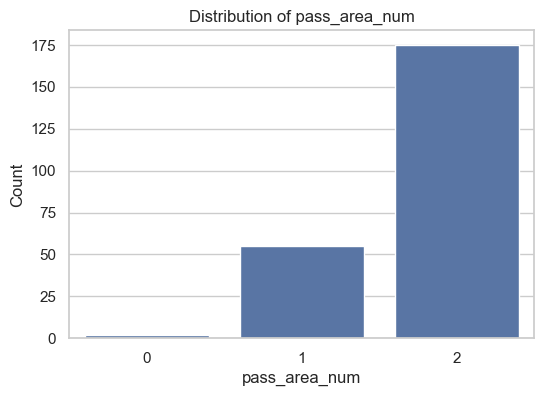

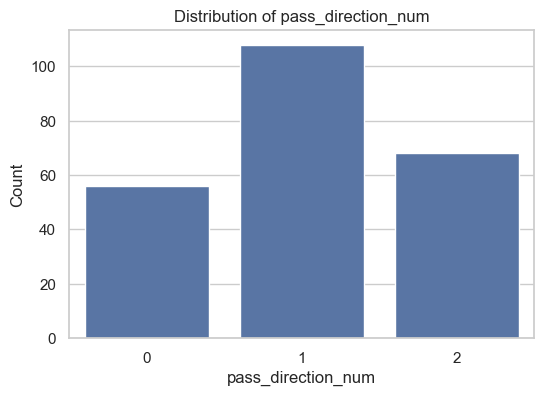

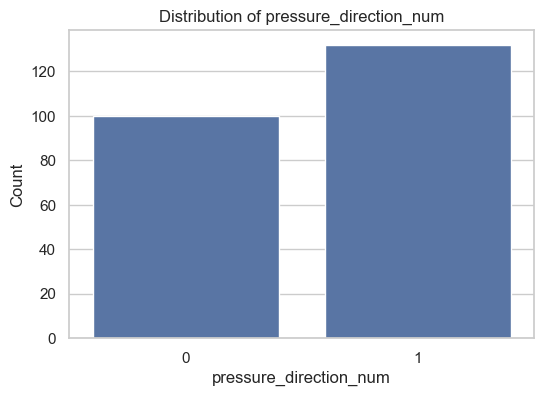

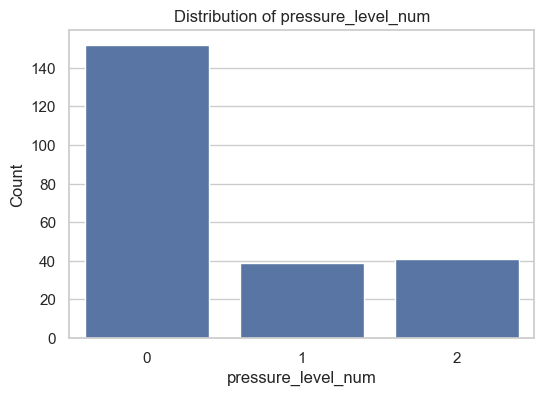

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置风格
sns.set(style="whitegrid")

# 分类变量列表（你可根据自己的列名替换）
categorical_vars = ['pass_area_num', 'pass_direction_num', 'pressure_direction_num', 'pressure_level_num']

# 循环画图
for col in categorical_vars:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_selected, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


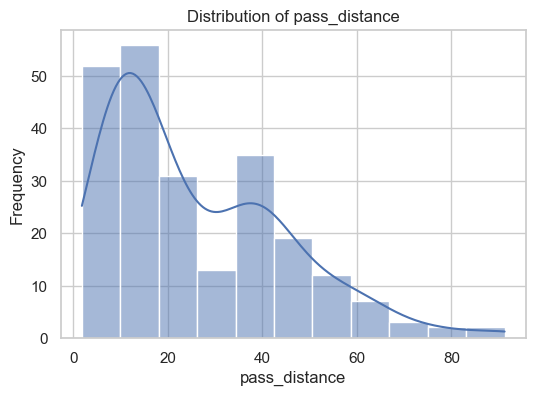

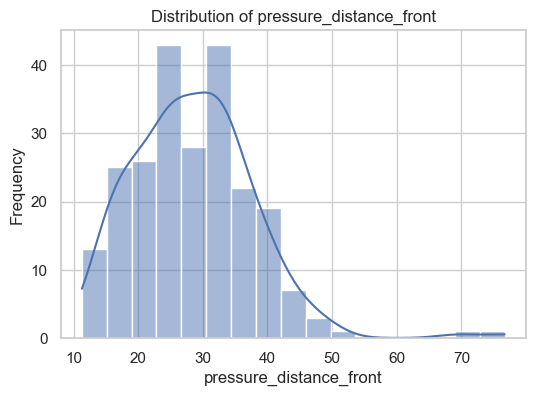

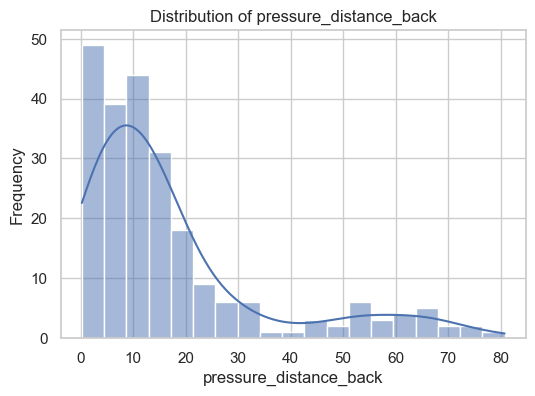

In [35]:
# 数值型变量（例如：传球距离、压力距离）
numeric_vars = ['pass_distance', 'pressure_distance_front', 'pressure_distance_back']

for col in numeric_vars:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_selected, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


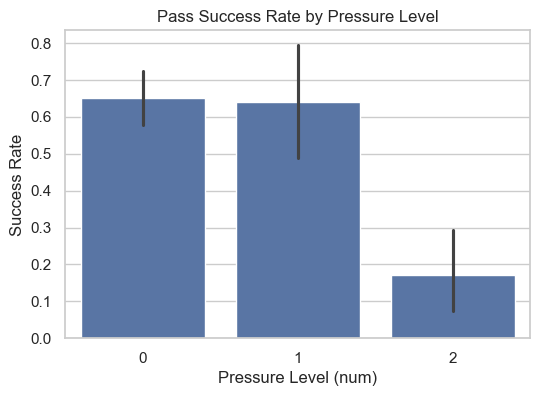

In [10]:
# 传球成功率 vs 不同压力等级、区域等
plt.figure(figsize=(6, 4))
sns.barplot(data=df_selected, x='pressure_level_num', y='pass_success')
plt.title('Pass Success Rate by Pressure Level')
plt.xlabel('Pressure Level (num)')
plt.ylabel('Success Rate')
plt.show()


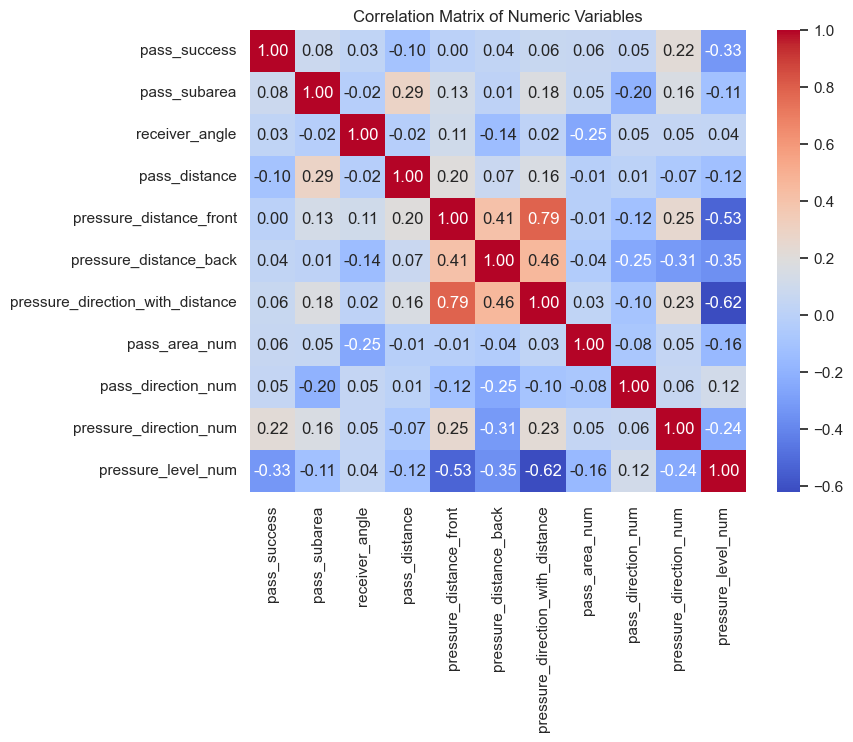

In [11]:
# 相关性矩阵（只对数值型）
plt.figure(figsize=(8, 6))
sns.heatmap(df_selected.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()


In [13]:

df_passes = pd.read_excel('graduation_thesis_test.xlsx', sheet_name='passes')
df_passes['timestamp'] = pd.to_datetime(df_passes['timestamp'], unit='ms')
# coordinates 表中的时间已经是标准时间，直接读取时设定 parse_dates
df_coordinates = pd.read_excel('graduation_thesis_test.xlsx', sheet_name='coordinates', parse_dates=['timestamp'])


In [14]:
df_passes.head()


,Unnamed: 0,timestamp,ballId,ballposX,ballposY,Match_id,matchDuration,startTime,Type,passedPlayerId,...,teamMatePlayerId8_xT_gained,teamMatePlayerId9_xT_end,teamMatePlayerId9_xT_gained,teamMatePlayerId10_xT_end,teamMatePlayerId10_xT_gained,extracted_File,event_id,normal_time,normal_receiver_time,noo
0,0,2017-08-20 22:28:59.602,304B,26.57,12.94,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96844,...,0.001,0.006,0.002,0.000,-0.004,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968446813960_13847,2017-08-20 22:28:59.602,1970-01-01 00:00:00.000,0
1,1,2017-08-20 22:29:10.805,304B,17.99,32.73,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96846,...,0.000,0.006,0.002,0.000,-0.004,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968466815080_52185,2017-08-20 22:29:10.805,2017-08-20 22:29:11.014,0
2,2,2017-08-20 22:29:38.811,304B,36.21,39.36,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96841,...,-0.005,0.005,-0.003,0.005,-0.003,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968416817880_73991,2017-08-20 22:29:38.811,1970-01-01 00:00:00.000,0
3,3,2017-08-20 22:30:01.815,304B,89.32,19.20,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96871,...,-0.006,0.000,-0.011,0.000,-0.011,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968716820180_48715,2017-08-20 22:30:01.815,2017-08-20 22:30:02.002,0
4,4,2017-08-20 22:30:05.206,304B,78.37,25.69,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96873,...,0.001,0.000,-0.004,0.000,-0.004,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968736820520_19089,2017-08-20 22:30:05.206,2017-08-20 22:30:05.206,0


In [15]:
df_coordinates.head()

,Unnamed: 0,timestamp,ballId,ballposX,ballposY,playerId0,posX0,posY0,playerId1,posX1,...,posY36,playerId37,posX37,posY37,playerId38,posX38,posY38,playerId39,posX39,posY39
0,0,2017-08-20 22:28:27.400,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,28.484375,...,29.05,96880,55.93750,24.828125,96855,47.59375,43.12500,96845,32.062500,34.03125
1,1,2017-08-20 22:28:27.601,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,28.781250,...,29.00,96880,56.12500,24.968750,96855,49.12500,43.09375,96845,31.953125,34.09375
2,2,2017-08-20 22:28:27.800,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,28.937500,...,29.00,96880,55.75000,24.937500,96855,49.00000,43.00000,96845,31.890625,34.18750
3,3,2017-08-20 22:28:28.147,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,29.000000,...,29.00,96880,55.56250,25.015625,96855,50.00000,43.37500,96845,31.875000,34.28125
4,4,2017-08-20 22:28:28.200,304B,-100.0,-100.0,96851,-100.0,-100.0,96844,29.000000,...,29.00,96880,54.84375,25.546875,96855,50.31250,43.43750,96845,31.921875,34.50000


In [17]:
import numpy as np

# 确保 coordinates 表按时间排序
df_coordinates = df_coordinates.sort_values('timestamp')

# 定义速度计算函数
def compute_pass_speed_from_coordinates(pass_time):
    # 找到这一传球时间在 coordinates 表中的索引位置
    i = df_coordinates['timestamp'].searchsorted(pass_time)
    
    # 如果时间超出范围，返回 NaN
    if i >= len(df_coordinates) - 1:
        return np.nan
    
    # 当前帧和下一帧
    x1, y1 = df_coordinates.iloc[i]['ballposX'], df_coordinates.iloc[i]['ballposY']
    t1 = df_coordinates.iloc[i]['timestamp']
    
    x2, y2 = df_coordinates.iloc[i+4]['ballposX'], df_coordinates.iloc[i+1]['ballposY']
    t2 = df_coordinates.iloc[i+4]['timestamp']
    
    # 时间差（秒）
    dt = (t2 - t1).total_seconds()
    if dt == 0:
        return np.nan
    
    # 距离
    dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    # 速度 = 距离 / 时间
    return dist / dt

# 应用于每条传球记录
df_passes['pass_speed'] = df_passes['timestamp'].apply(compute_pass_speed_from_coordinates)


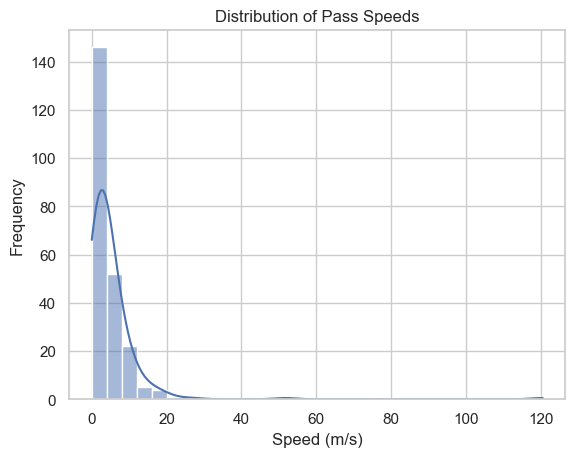

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_passes['pass_speed'].dropna(), bins=30, kde=True)
plt.title("Distribution of Pass Speeds")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")
plt.show()


In [19]:
print(df_passes[['timestamp', 'pass_speed']].head(10))


                timestamp  pass_speed
0 2017-08-20 22:28:59.602   11.799645
1 2017-08-20 22:29:10.805    3.734071
2 2017-08-20 22:29:38.811    5.106036
3 2017-08-20 22:30:01.815    0.405063
4 2017-08-20 22:30:05.206    5.726419
5 2017-08-20 22:30:27.403    7.635373
6 2017-08-20 22:30:42.014    4.791553
7 2017-08-20 22:30:49.201    0.900434
8 2017-08-20 22:30:51.804    5.288945
9 2017-08-20 22:30:52.406    2.628554


In [20]:
num_zero_speed = (df_passes['pass_speed'] == 0).sum()
print(f"球速为 0 的传球数量：{num_zero_speed}")


球速为 0 的传球数量：1


In [21]:

df_abnormal = df_passes[df_passes['pass_speed'] == 0]

# 显示这些记录的关键信息
print(df_abnormal[['timestamp', 'pass_speed', 'passedPlayerPosX', 'passedPlayerPosY',
                   'receivedPlayerPosX', 'receivedPlayerPosY', 'isSucceeded']])



                  timestamp  pass_speed  passedPlayerPosX  passedPlayerPosY  \
217 2017-08-20 23:45:20.603         0.0             98.79             13.13   

     receivedPlayerPosX  receivedPlayerPosY  isSucceeded  
217               32.77                -1.3            0  


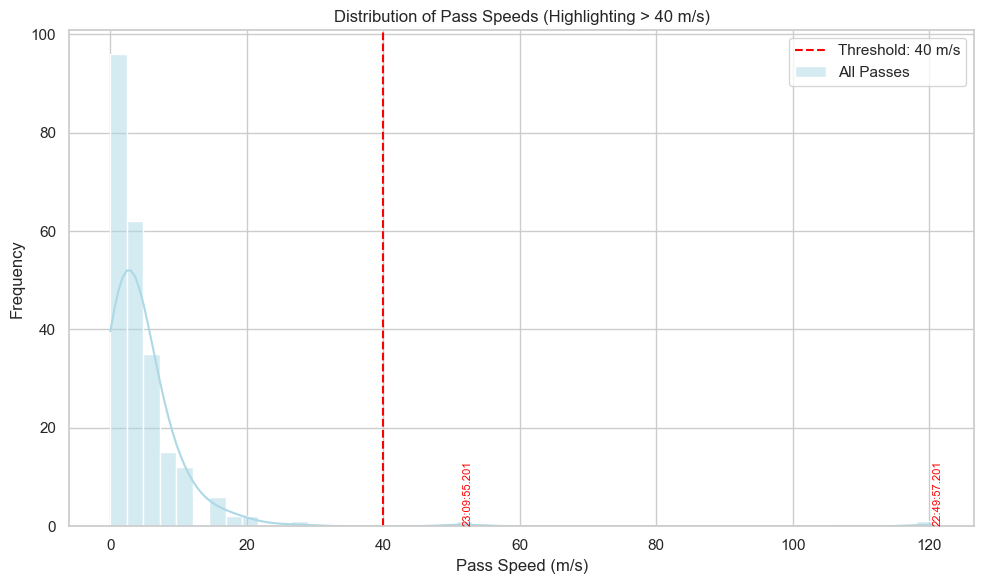

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 创建数据子集
fast_passes = df_passes[df_passes['pass_speed'] > 40]

# 绘制全体球速分布
plt.figure(figsize=(10, 6))
sns.histplot(df_passes['pass_speed'], bins=50, kde=True, color='lightblue', label='All Passes')
plt.axvline(40, color='red', linestyle='--', label='Threshold: 40 m/s')

# 在图中加上异常点
for i, row in fast_passes.iterrows():
    plt.text(row['pass_speed'], 0.5, row['timestamp'].strftime('%H:%M:%S.%f')[:-3],
             rotation=90, fontsize=8, color='red')

plt.title('Distribution of Pass Speeds (Highlighting > 40 m/s)')
plt.xlabel('Pass Speed (m/s)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# 找出异常球速的传球记录（超过 40 m/s）
df_abnormal = df_passes[df_passes['pass_speed'] > 40]

# 显示这些记录的关键信息
print(df_abnormal[['timestamp', 'pass_speed', 'passedPlayerPosX', 'passedPlayerPosY',
                   'receivedPlayerPosX', 'receivedPlayerPosY', 'isSucceeded']])



                  timestamp  pass_speed  passedPlayerPosX  passedPlayerPosY  \
65  2017-08-20 22:49:57.201  120.522822              1.12             35.47   
138 2017-08-20 23:09:55.201   51.605534              6.96             32.47   

     receivedPlayerPosX  receivedPlayerPosY  isSucceeded  
65                -2.27               31.83            0  
138               20.16               72.05            0  


In [24]:
# 去除异常球速：0 或 > 40 m/s
df_passes_cleaned = df_passes[
    (df_passes['pass_speed'] > 0) & (df_passes['pass_speed'] <= 40)
].copy()

# 查看剩下的球速分布（可选）
print(df_passes_cleaned['pass_speed'].describe())


count    230.000000
mean       4.302000
std        4.180379
min        0.012077
25%        1.643407
50%        2.835119
75%        5.683148
max       26.715066
Name: pass_speed, dtype: float64


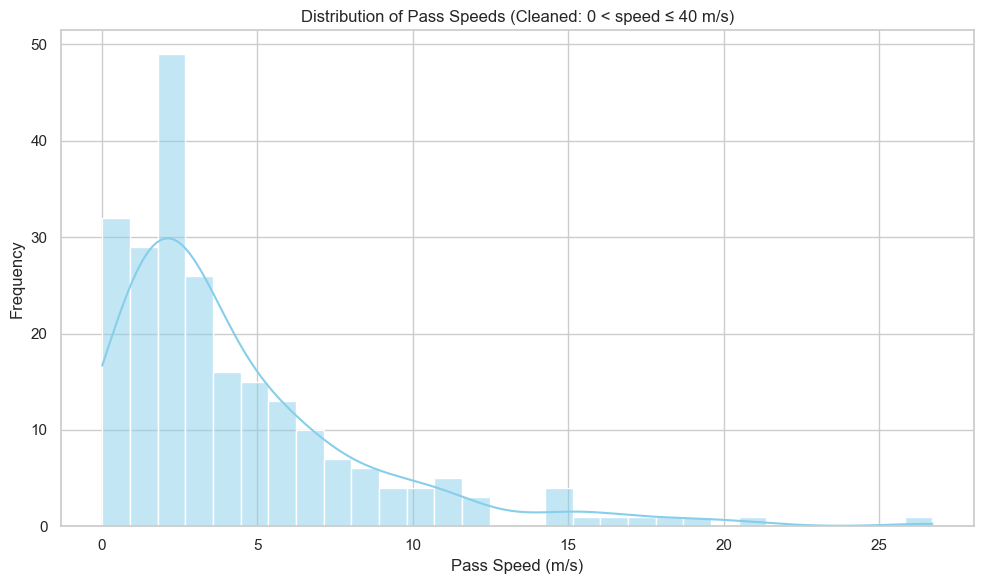

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 画球速分布直方图（不含异常值）
plt.figure(figsize=(10, 6))
sns.histplot(df_passes_cleaned['pass_speed'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Pass Speeds (Cleaned: 0 < speed ≤ 40 m/s)')
plt.xlabel('Pass Speed (m/s)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
df_passes_cleaned = df_passes_cleaned[df_passes_cleaned['passedPlayer_Zone'] != '0.0']
# 构造映射字典
area_map = {'Defence': 0, 'Mid field': 1, 'Attack': 2}
pass_type_map = {'Backward pass': 0, 'Lateral pass': 1, 'Forward pass': 2}
pressure_dir_map = {'back': 0, 'front': 1}
pressure_level_map = {
    'No Pressure': 0,
    'Limited Pressure': 1,
    'Full Pressure': 2
}

# 映射变量名与你在 df_selected 中一致
df_passes_cleaned['pass_area_num'] = df_passes_cleaned['passedPlayer_Zone'].map(area_map)
df_passes_cleaned['pass_direction_num'] = df_passes_cleaned['receivedPlayerId_PassType'].map(pass_type_map)
df_passes_cleaned['pressure_direction_num'] = df_passes_cleaned['Pressure direction'].map(pressure_dir_map)
df_passes_cleaned['pressure_level_num'] = df_passes_cleaned['Pressure level'].map(pressure_level_map)


C:\Users\Adolph\AppData\Local\Temp\ipykernel_6600\3014415917.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['pass_area_num'] = df_passes_cleaned['passedPlayer_Zone'].map(area_map)
C:\Users\Adolph\AppData\Local\Temp\ipykernel_6600\3014415917.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['pass_direction_num'] = df_passes_cleaned['receivedPlayerId_PassType'].map(pass_type_map)
C:\Users\Adolph\AppData\Local\Temp\ipykernel_6600\3014415917.py:15: SettingWithCopyWar

In [50]:
df_passes_cleaned.head()


,Unnamed: 0,timestamp,ballId,ballposX,ballposY,Match_id,matchDuration,startTime,Type,passedPlayerId,...,extracted_File,event_id,normal_time,normal_receiver_time,noo,pass_speed,pass_area_num,pass_direction_num,pressure_direction_num,pressure_level_num
0,0,2017-08-20 22:28:59.602,304B,26.57,12.94,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96844,...,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968446813960_13847,2017-08-20 22:28:59.602,1970-01-01 00:00:00.000,0,11.799645,1,1,1,1
1,1,2017-08-20 22:29:10.805,304B,17.99,32.73,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96846,...,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968466815080_52185,2017-08-20 22:29:10.805,2017-08-20 22:29:11.014,0,3.734071,2,1,1,0
2,2,2017-08-20 22:29:38.811,304B,36.21,39.36,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96841,...,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968416817880_73991,2017-08-20 22:29:38.811,1970-01-01 00:00:00.000,0,5.106036,2,2,0,1
3,3,2017-08-20 22:30:01.815,304B,89.32,19.20,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96871,...,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968716820180_48715,2017-08-20 22:30:01.815,2017-08-20 22:30:02.002,0,0.405063,2,2,1,0
4,4,2017-08-20 22:30:05.206,304B,78.37,25.69,0F65BAAB-3EF8-4F3D-A44A-E70204AD0046,0 days 01:21:49.801000,1503268107400,Pass,96873,...,matches/0F65BAAB-3EF8-4F3D-A44A-E70204AD0046/S...,0F65BAAB968736820520_19089,2017-08-20 22:30:05.206,2017-08-20 22:30:05.206,0,5.726419,1,1,1,0


C:\Users\Adolph\AppData\Local\Temp\ipykernel_6600\1843131487.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_passes_cleaned, x='pressure_level_num', y='pass_speed',palette='Set2')


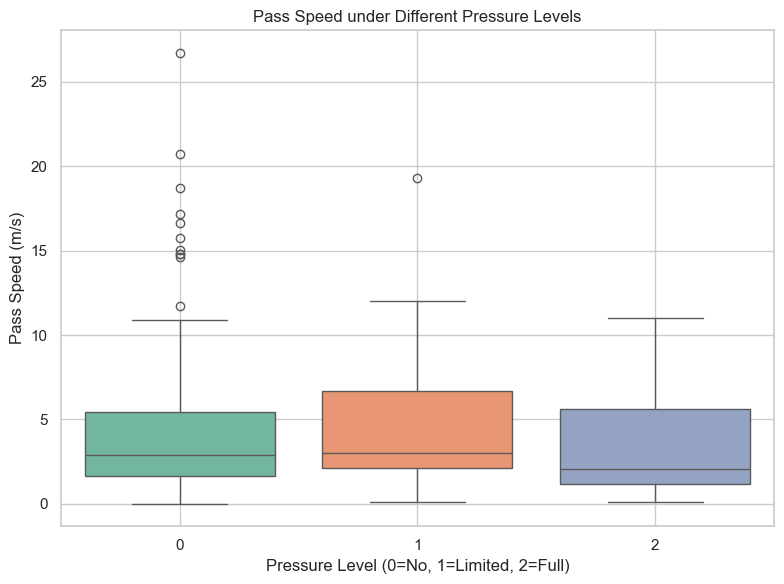

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# 箱线图：压力强度 vs 传球速度
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_passes_cleaned, x='pressure_level_num', y='pass_speed',palette='Set2')
plt.title('Pass Speed under Different Pressure Levels')
plt.xlabel('Pressure Level (0=No, 1=Limited, 2=Full)')
plt.ylabel('Pass Speed (m/s)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [52]:
from scipy.stats import f_oneway

# 按压力强度分组
groups = [group['pass_speed'].dropna() for _, group in df_passes_cleaned.groupby('pressure_level_num')]

# 单因素方差分析
f_stat, p_val = f_oneway(*groups)
print(f"ANOVA F值 = {f_stat:.2f}, p值 = {p_val:.4f}")


ANOVA F值 = 1.04, p值 = 0.3538


In [34]:
import sys
!{sys.executable} -m pip install statsmodels

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.8 MB 7.4 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.8 MB 8.0 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.8 MB 7.9 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 8.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 8.7 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmode

In [53]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols('pass_speed ~ C(pressure_level_num) * C(pressure_direction_num)', data=df_passes_cleaned).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                                      sum_sq     df         F  \
C(pressure_level_num)                              39.574661    2.0  1.114001   
C(pressure_direction_num)                          15.312656    1.0  0.862083   
C(pressure_level_num):C(pressure_direction_num)     3.068106    2.0  0.086365   
Residual                                         3943.250895  222.0       NaN   

                                                   PR(>F)  
C(pressure_level_num)                            0.330071  
C(pressure_direction_num)                        0.354165  
C(pressure_level_num):C(pressure_direction_num)  0.917290  
Residual                                              NaN  


In [54]:
# 重新计算真实平均球速
mean_speeds = df_passes_cleaned.groupby('pressure_level_num')['pass_speed'].mean()
print(mean_speeds)


pressure_level_num
0    4.399060
1    4.827791
2    3.523109
Name: pass_speed, dtype: float64


In [55]:
# 回归模型：球速 ~ 压力等级 + 压力方向 + 区域 + 类型 + 距离（控制变量）
model = smf.ols(
    'pass_speed ~ C(pressure_level_num) + C(pressure_direction_num) + C(pass_area_num) + C(pass_direction_num) + receivedPlayerId_PassLength',
    data=df_passes_cleaned
).fit()

# 输出回归摘要
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             pass_speed   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.8974
Date:                Sat, 14 Jun 2025   Prob (F-statistic):              0.519
Time:                        16:51:30   Log-Likelihood:                -646.37
No. Observations:                 228   AIC:                             1311.
Df Residuals:                     219   BIC:                             1342.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

C:\Users\Adolph\AppData\Local\Temp\ipykernel_6600\1980604078.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['predicted_speed'] = model.fittedvalues
C:\Users\Adolph\AppData\Local\Temp\ipykernel_6600\1980604078.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passes_cleaned['pressure_level_label'] = df_passes_cleaned['pressure_level_num'].map(pressure_level_labels)
C:\Users\Adolph\AppData\Local\Temp\ipykernel_6600\1980604078.py:17: FutureWarning: 

Passing `palette` without assig

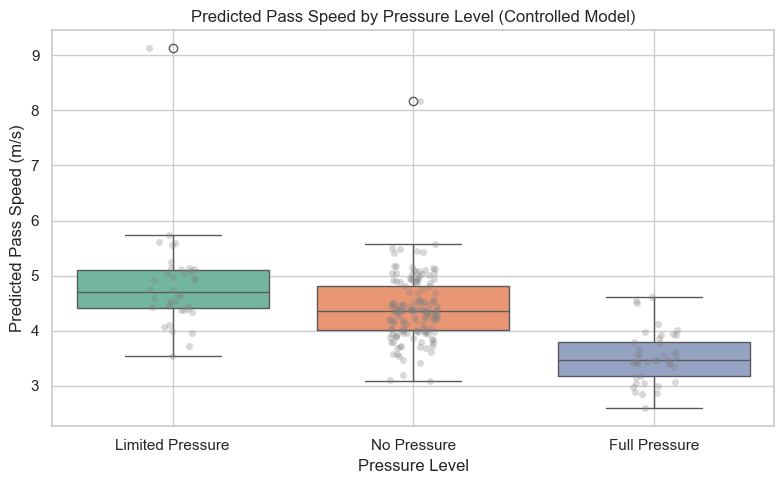

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你已有 model.fittedvalues 和 pressure_level_num 列
df_passes_cleaned['predicted_speed'] = model.fittedvalues

# 映射压力等级标签
pressure_level_labels = {
    0: 'No Pressure',
    1: 'Limited Pressure',
    2: 'Full Pressure'
}
df_passes_cleaned['pressure_level_label'] = df_passes_cleaned['pressure_level_num'].map(pressure_level_labels)

# 绘制箱线图（可加 stripplot 叠加点分布）
plt.figure(figsize=(8, 5))
sns.boxplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, palette='Set2')
sns.stripplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, color='gray', alpha=0.3, jitter=True)

plt.title("Predicted Pass Speed by Pressure Level (Controlled Model)")
plt.xlabel("Pressure Level")
plt.ylabel("Predicted Pass Speed (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Adolph\AppData\Local\Temp\ipykernel_6600\3527901461.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, estimator='mean', ci='sd')


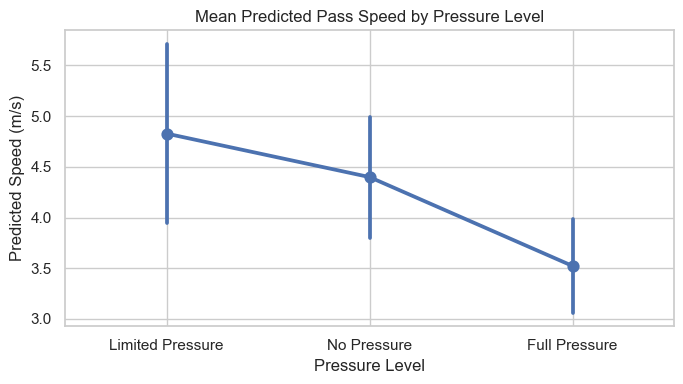

In [57]:
# 折线图：平均预测速度 vs 压力等级
plt.figure(figsize=(7, 4))
sns.pointplot(x='pressure_level_label', y='predicted_speed', data=df_passes_cleaned, estimator='mean', ci='sd')
plt.title("Mean Predicted Pass Speed by Pressure Level")
plt.xlabel("Pressure Level")
plt.ylabel("Predicted Speed (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()


# The role of ball speed on passing outcomes

In [62]:
import statsmodels.formula.api as smf

model_logit = smf.logit(
    'isSucceeded ~ pass_speed + receivedPlayerId_PassLength + C(pressure_level_num) + C(pass_area_num) + C(pass_direction_num)',
    data=df_passes_cleaned
).fit(maxiter=100)
print(model_logit.summary())


         Current function value: 0.582127
         Iterations: 100
                           Logit Regression Results                           
Dep. Variable:            isSucceeded   No. Observations:                  228
Model:                          Logit   Df Residuals:                      219
Method:                           MLE   Df Model:                            8
Date:                Sat, 14 Jun 2025   Pseudo R-squ.:                  0.1480
Time:                        17:44:51   Log-Likelihood:                -132.72
converged:                      False   LL-Null:                       -155.78
Covariance Type:            nonrobust   LLR p-value:                 2.256e-07
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      23.4949   1.02e+05      0.000      1.000   -2.01e+05    2.01e+05
C(pressure_le

C:\Users\Adolph\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "














# 窗口分析

KeyError: 'xT_change'